<a href="https://colab.research.google.com/github/navadiyajils007-pixel/aiml_assignment/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("dice_histograms", exist_ok=True)

dice_counts = range(1, 51)
trials = [100, 500, 1000, 5000, 10000, 50000, 100000]

for num_dice in dice_counts:
    fig, axes = plt.subplots(len(trials), 1, figsize=(8, 4 * len(trials)))
    fig.suptitle(f'Sum Histograms: {num_dice} Dice', fontsize=16)

    for i, n_trials in enumerate(trials):
        rolls = np.random.randint(1, 7, size=(n_trials, num_dice))
        sums = np.sum(rolls, axis=1)

        mean_val = np.mean(sums)
        var_val = np.var(sums)
        print(f"{num_dice} Dice | Trials: {n_trials} | Mean: {mean_val:.3f} | Variance: {var_val:.3f}")

        bins = np.arange(num_dice - 0.5, (num_dice * 6) + 1.5, 1)
        axes[i].hist(sums, bins=bins, density=True, alpha=0.7, color='skyblue', edgecolor='black')
        axes[i].set_title(f'{n_trials} Trials')

    plt.tight_layout()
    plt.savefig(f"dice_histograms/rolls_{num_dice}_dice.png")
    plt.close()

1 Dice | Trials: 100 | Mean: 3.060 | Variance: 2.096
1 Dice | Trials: 500 | Mean: 3.474 | Variance: 2.881
1 Dice | Trials: 1000 | Mean: 3.534 | Variance: 2.799
1 Dice | Trials: 5000 | Mean: 3.498 | Variance: 2.862
1 Dice | Trials: 10000 | Mean: 3.503 | Variance: 2.936
1 Dice | Trials: 50000 | Mean: 3.498 | Variance: 2.926
1 Dice | Trials: 100000 | Mean: 3.499 | Variance: 2.910
2 Dice | Trials: 100 | Mean: 6.900 | Variance: 5.870
2 Dice | Trials: 500 | Mean: 7.014 | Variance: 5.710
2 Dice | Trials: 1000 | Mean: 6.985 | Variance: 5.663
2 Dice | Trials: 5000 | Mean: 6.967 | Variance: 5.902
2 Dice | Trials: 10000 | Mean: 6.994 | Variance: 5.809
2 Dice | Trials: 50000 | Mean: 7.007 | Variance: 5.830
2 Dice | Trials: 100000 | Mean: 7.009 | Variance: 5.858
3 Dice | Trials: 100 | Mean: 10.950 | Variance: 11.527
3 Dice | Trials: 500 | Mean: 10.840 | Variance: 7.998
3 Dice | Trials: 1000 | Mean: 10.510 | Variance: 8.742
3 Dice | Trials: 5000 | Mean: 10.496 | Variance: 8.808
3 Dice | Trials: 1000

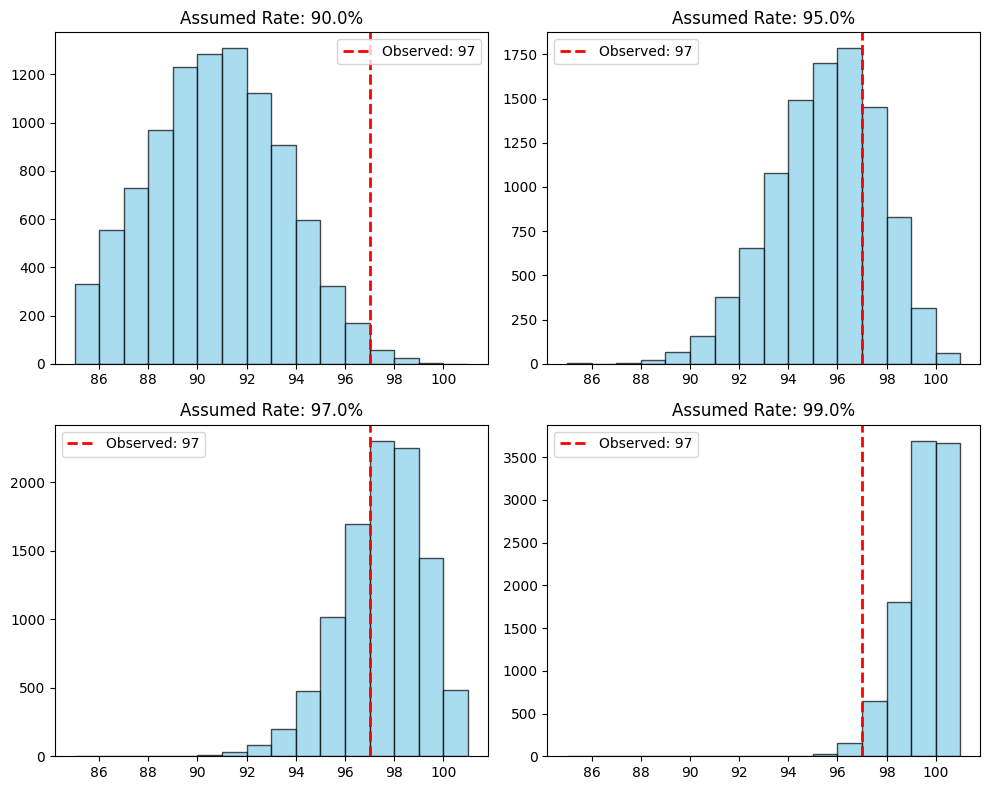

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_reviews = 100
observed = 97
hypothetical_rates = [0.90, 0.95, 0.97, 0.99]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, p in enumerate(hypothetical_rates):
    simulated = np.random.binomial(n=n_reviews, p=p, size=10000)
    axes[i].hist(simulated, bins=range(85, 102), alpha=0.7, color='skyblue', edgecolor='black')

    axes[i].axvline(observed, color='red', linestyle='dashed', linewidth=2, label=f'Observed: {observed}')
    axes[i].set_title(f'Assumed Rate: {p*100}%')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from scipy.stats import entropy

df_adv = pd.read_csv('/advertising.csv')

entropies = {}

for col in df_adv.columns:
    if df_adv[col].dtype == 'object' or df_adv[col].nunique() < 10:
        counts = df_adv[col].value_counts()
    else:
        counts = pd.cut(df_adv[col], bins=10).value_counts()

    entropies[col] = entropy(counts, base=2)

print("Entropy for each column in advertising.csv:")
for col, ent in entropies.items():
    print(f"{col}: {ent:.4f} bits")

Entropy for each column in advertising.csv:
TV: 3.2985 bits
Radio: 3.2896 bits
Newspaper: 2.7522 bits
Sales: 3.0530 bits


In [ ]:
import pandas as pd

df_sport = pd.read_csv('/enjoy_sport.csv')

X = df_sport.iloc[:, :-1].values
y = df_sport.iloc[:, -1].values

def find_s_algorithm(attributes, target):
    S = None

    for i, label in enumerate(target):
        if label == 'Yes':
            if S is None:
                S = list(attributes[i])
            else:
                for j in range(len(S)):
                    if S[j] != attributes[i][j]:
                        S[j] = '?'
    return S

maximal_specific_hypothesis = find_s_algorithm(X, y)
print("Maximal Specific Hypothesis (Find-S):")
print(maximal_specific_hypothesis)

Maximal Specific Hypothesis (Find-S):
['Sunny', 'Warm', '?', '?', '?', '?']


In [ ]:
import pandas as pd
import itertools

df_sport = pd.read_csv('/enjoy_sport.csv')

X = df_sport.iloc[:, :-1].values
y = df_sport.iloc[:, -1].values

def list_then_eliminate(attributes, target):
    domains = [list(set([row[i] for row in attributes])) for i in range(len(attributes[0]))]

    hypothesis_domains = [d + ['?'] for d in domains]

    print("Generating the complete hypothesis space...")
    all_hypotheses = list(itertools.product(*hypothesis_domains))

    all_hypotheses.append(tuple(['0'] * len(attributes[0])))

    version_space = all_hypotheses.copy()

    def covers(h, x):
        if h == tuple(['0'] * len(x)):
            return False
        for h_val, x_val in zip(h, x):
            if h_val != '?' and h_val != x_val:
                return False
        return True

    print(f"Initial Version Space size: {len(version_space)} hypotheses")

    for i in range(len(attributes)):
        instance = attributes[i]
        label = target[i]

        remaining_hypotheses = []

        for h in version_space:
            is_covered = covers(h, instance)

            if label == 'Yes' and is_covered:
                remaining_hypotheses.append(h)
            elif label == 'No' and not is_covered:
                remaining_hypotheses.append(h)

        version_space = remaining_hypotheses
        print(f"After instance {i+1} ({label}), remaining hypotheses: {len(version_space)}")

    return version_space

final_version_space = list_then_eliminate(X, y)

print("\nFinal Version Space (List Candidate Method):")
for idx, hypothesis in enumerate(final_version_space):
    print(f"{idx + 1}. {hypothesis}")

Generating the complete hypothesis space...
Initial Version Space size: 973 hypotheses
After instance 1 (Yes), remaining hypotheses: 64
After instance 2 (Yes), remaining hypotheses: 32
After instance 3 (No), remaining hypotheses: 28
After instance 4 (Yes), remaining hypotheses: 6
After instance 5 (No), remaining hypotheses: 5
After instance 6 (No), remaining hypotheses: 4
After instance 7 (No), remaining hypotheses: 3
After instance 8 (Yes), remaining hypotheses: 1
After instance 9 (Yes), remaining hypotheses: 1
After instance 10 (No), remaining hypotheses: 1
After instance 11 (Yes), remaining hypotheses: 1
After instance 12 (No), remaining hypotheses: 1

Final Version Space (List Candidate Method):
1. ('Sunny', 'Warm', '?', '?', '?', '?')
